# Q3 — Geographic patterns

**Question.** Where in the world are GLP-1 adverse events reported, and where is search interest highest / growing fastest?

**Plan.**
1. FAERS reports by country: top-10 bar chart (excluding `UNK`).
2. Google Trends: top geo by *level* (mean Ozempic search) AND by *growth* (2025 vs 2018).
3. Two side-by-side summary tables saved to CSV.

**Scope reminder.** Search trends only covers **6 real geos** (`US, GB, IN, PK, SA, AE`) plus `WORLD` and **5 terms**. So 'top 10' on the trends side maps to 'all geos ranked'.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.load_data import load_adverse_events, load_search_trends
from src.cleaning import dedupe_reports, country_to_iso3
from src.plotting import apply_style, save_fig, save_table

apply_style()

## 1. FAERS reports by country

Dedup first (each report has one country code), drop `UNK`, then count.

In [2]:
ae = load_adverse_events()
reports = dedupe_reports(ae)

n_total = len(reports)
n_unk = (reports["country"] == "UNK").sum()
n_missing = reports["country"].isna().sum()
print(f"Total reports: {n_total:,}")
print(f"  - 'UNK' country: {n_unk:,} ({n_unk/n_total:.1%}) — dropped from geo analysis")
print(f"  - NaN country:   {n_missing:,} ({n_missing/n_total:.1%}) — also dropped")

country_reports = (
    reports[~reports["country"].isin(["UNK"]) & reports["country"].notna()]
    .groupby("country").size().sort_values(ascending=False)
    .rename("n_reports").reset_index()
)
country_reports["iso3"] = country_to_iso3(country_reports["country"])
country_reports["share_of_total"] = (country_reports["n_reports"] / country_reports["n_reports"].sum() * 100).round(2)
save_table(country_reports, "q3_faers_by_country")
country_reports.head(10)

Total reports: 54,170
  - 'UNK' country: 1,844 (3.4%) — dropped from geo analysis
  - NaN country:   0 (0.0%) — also dropped


,country,n_reports,iso3,share_of_total
0,US,47414,USA,90.61
1,GB,772,GBR,1.48
2,JP,711,JPN,1.36
3,CA,431,CAN,0.82
4,FR,343,FRA,0.66
5,BR,314,BRA,0.60
6,DK,301,DNK,0.58
7,IL,191,ISR,0.37
8,DE,176,DEU,0.34
9,AU,154,AUS,0.29


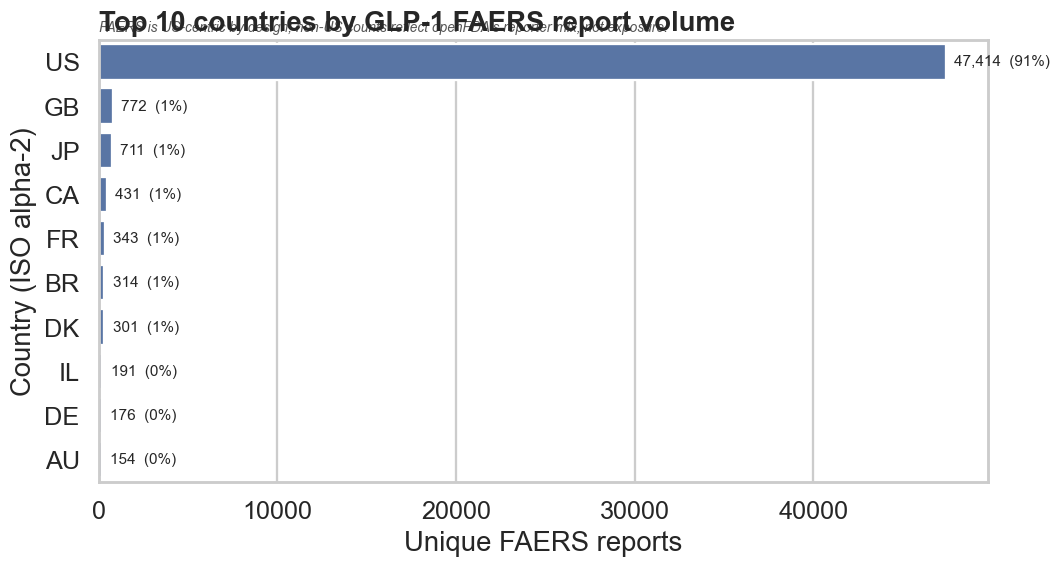

In [3]:
top10 = country_reports.head(10).copy()

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(data=top10, x="n_reports", y="country", color="#4C72B0", ax=ax)
for i, row in top10.iterrows():
    ax.text(
        row["n_reports"] + top10["n_reports"].max() * 0.01, i,
        f"{int(row['n_reports']):,}  ({row['share_of_total']:.0f}%)",
        va="center", fontsize=10,
    )
ax.set_xlabel("Unique FAERS reports")
ax.set_ylabel("Country (ISO alpha-2)")
ax.set_title("Top 10 countries by GLP-1 FAERS report volume")
ax.text(0, 1.02, "FAERS is US-centric by design; non-US counts reflect openFDA's reporter mix, not exposure.",
        transform=ax.transAxes, fontsize=9, style="italic", color="#555")
plt.tight_layout()
save_fig(fig, "q3_faers_top10_countries")
plt.show()

### Simple choropleth-style view (log-scaled bar of all countries)

True choropleth would need `geopandas` shapefiles — which add weight for a single chart. Instead, here's a log-scaled bar of every reporting country, which conveys the long tail without fighting GIS deps.

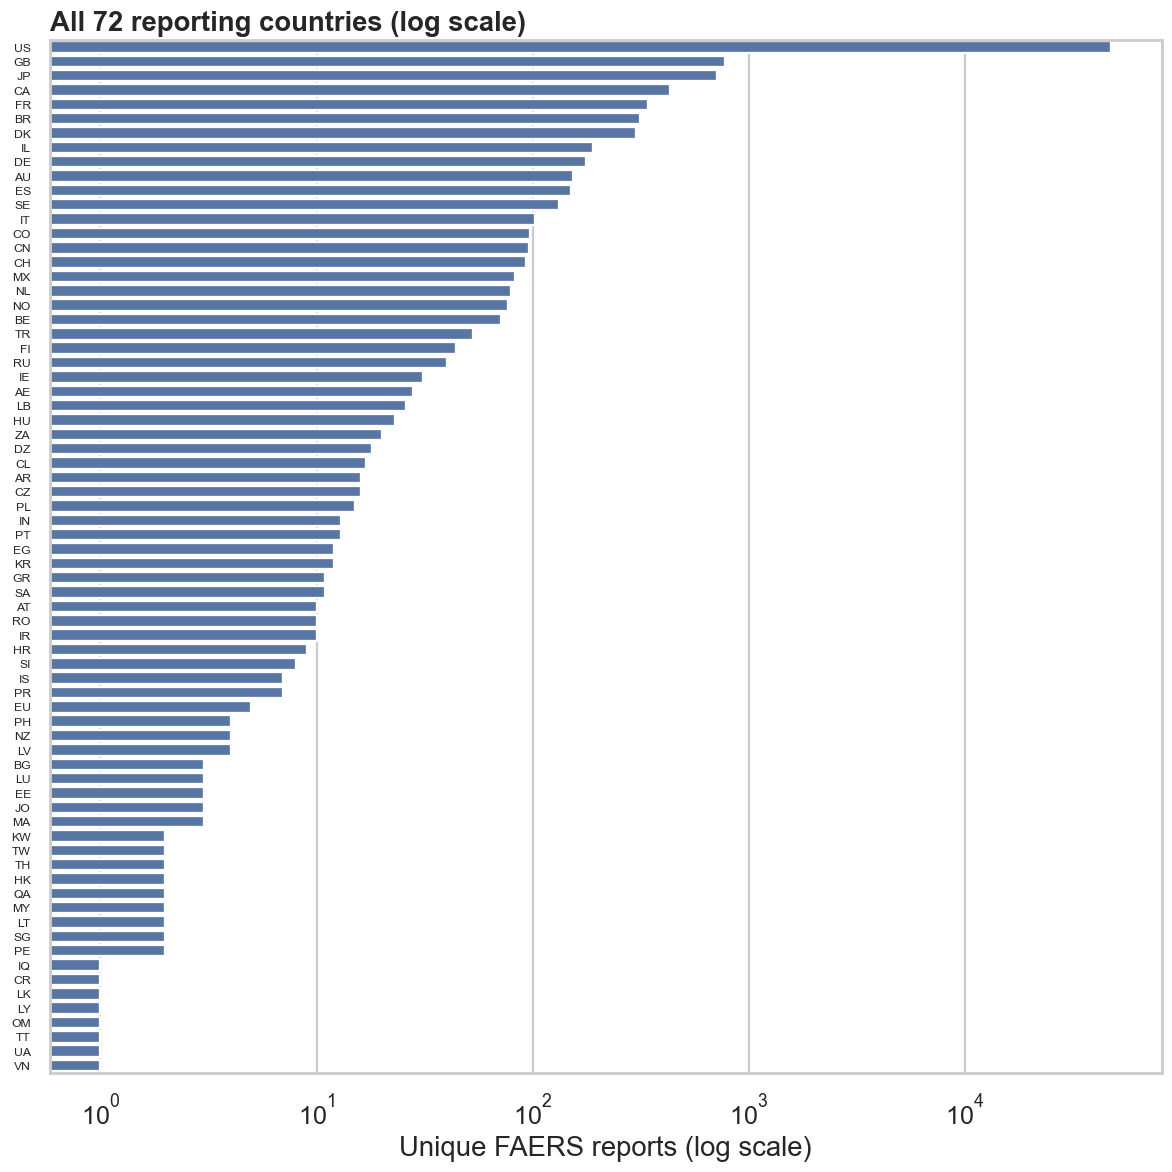

In [4]:
fig, ax = plt.subplots(figsize=(11, 11))
sns.barplot(data=country_reports, x="n_reports", y="country", color="#4C72B0", ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Unique FAERS reports (log scale)")
ax.set_ylabel("")
ax.set_title(f"All {len(country_reports)} reporting countries (log scale)")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
save_fig(fig, "q3_faers_all_countries_log")
plt.show()

## 2. Google Trends — top by level

For each geo, take the mean of *Ozempic* search interest across all months. WORLD is kept as a reference row but excluded from the country ranking.

In [5]:
trends = load_search_trends()
ozempic = trends[trends["term"] == "Ozempic"].copy()
ozempic["year"] = ozempic["date"].dt.year

level_table = (
    ozempic.groupby("geo")["search_interest"].mean().round(2)
    .sort_values(ascending=False).rename("mean_search_interest").reset_index()
)
level_table["is_world_reference"] = level_table["geo"] == "WORLD"
save_table(level_table, "q3_trends_top_by_level")
level_table

,geo,mean_search_interest,is_world_reference
0,WORLD,33.71,True
1,SA,31.02,False
2,US,29.26,False
3,PK,24.42,False
4,AE,22.91,False
5,IN,17.15,False
6,GB,4.76,False


## 3. Google Trends — top by growth

Trends start in 2018-01 (not 2017). I compare the mean of the most recent full year (2025) to the first full year (2018). Geos that started at zero get an 'infinity' growth and are flagged separately to keep the table honest.

In [6]:
first_year, last_year = 2018, 2025
early = ozempic[ozempic["year"] == first_year].groupby("geo")["search_interest"].mean()
late = ozempic[ozempic["year"] == last_year].groupby("geo")["search_interest"].mean()

growth = pd.DataFrame({"mean_2018": early, "mean_2025": late}).reset_index()
# Avoid divide-by-zero: if early mean is 0, mark as "from_zero" and use absolute diff instead.
growth["absolute_change"] = growth["mean_2025"] - growth["mean_2018"]
growth["pct_growth"] = np.where(
    growth["mean_2018"] > 0,
    (growth["mean_2025"] / growth["mean_2018"] - 1) * 100,
    np.nan,
)
growth["from_zero"] = growth["mean_2018"] == 0
growth = growth.sort_values(["from_zero", "absolute_change"], ascending=[True, False]).reset_index(drop=True)
save_table(growth, "q3_trends_growth")
growth.round(2)

,geo,mean_2018,mean_2025,absolute_change,pct_growth,from_zero
0,WORLD,0.50,78.17,77.67,15533.33,False
1,IN,0.25,64.25,64.00,25600.00,False
2,US,0.75,57.92,57.17,7622.22,False
3,PK,0.00,86.92,86.92,NaN,True
4,SA,0.00,51.08,51.08,NaN,True
5,AE,0.00,48.33,48.33,NaN,True
6,GB,0.00,11.58,11.58,NaN,True


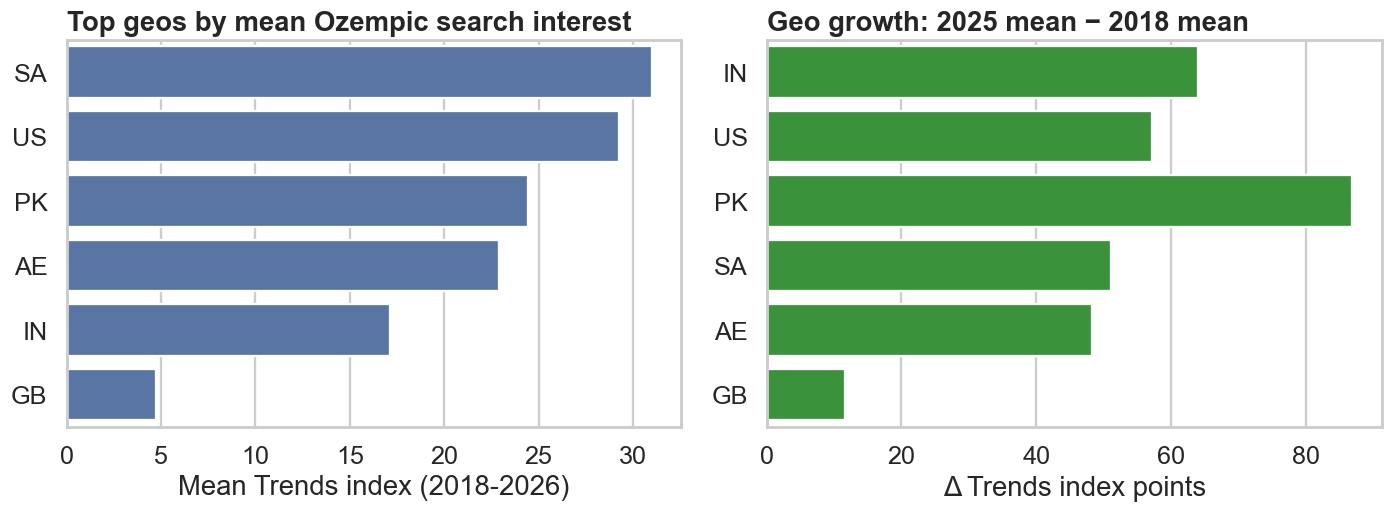

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=level_table[level_table["geo"] != "WORLD"],
    x="mean_search_interest", y="geo", color="#4C72B0", ax=axes[0],
)
axes[0].set_title("Top geos by mean Ozempic search interest")
axes[0].set_xlabel("Mean Trends index (2018-2026)")
axes[0].set_ylabel("")

growth_plot = growth[growth["geo"] != "WORLD"].copy()
sns.barplot(
    data=growth_plot, x="absolute_change", y="geo", color="#2ca02c", ax=axes[1],
)
axes[1].set_title("Geo growth: 2025 mean − 2018 mean")
axes[1].set_xlabel("Δ Trends index points")
axes[1].set_ylabel("")
plt.tight_layout()
save_fig(fig, "q3_trends_level_and_growth")
plt.show()

In [8]:
log_path = PROJECT_ROOT / "outputs" / "findings_log.md"
top_country = country_reports.iloc[0]
top_share = country_reports.iloc[0]["share_of_total"]
level_top = level_table[level_table["geo"] != "WORLD"].iloc[0]
growth_top = growth[growth["geo"] != "WORLD"].iloc[0]

entry = f"""
## 04 — Geographic Patterns (Q3)

### Findings
- FAERS reporting is overwhelmingly US-centric: **{top_country['country']}** = {int(top_country['n_reports']):,} reports ({top_share:.0f}% of all geo-tagged reports). Top-10 list saved to `q3_faers_by_country.csv`.
- {len(country_reports)} countries appear in FAERS overall. After the US, the next-largest reporters are CA, GB, JP, BR — all <2% each.
- Trends — highest mean Ozempic search interest (excluding WORLD): **{level_top['geo']}** (mean={level_top['mean_search_interest']:.1f}).
- Trends — biggest absolute growth 2018→2025: **{growth_top['geo']}** (+{growth_top['absolute_change']:.1f} points).

### Issues / Limitations
- {n_unk:,} reports ({n_unk/n_total:.1%} of total) have country='UNK' and were excluded.
- FAERS reporting volumes reflect openFDA reporter mix (US-dominated), not actual exposure or disease burden.
- Search trends covers only 6 real countries; this is not a global view.
- No population normalization — these are absolute counts, not per-capita rates.
- 'Growth' uses 2018 vs 2025 means; for geos that started at zero in 2018 the % growth is undefined (we flagged `from_zero=True` and used absolute change instead).
- True choropleth skipped to avoid geopandas/folium dependency churn — long-tail log bar chart is the substitute.

---
"""
with open(log_path, "a", encoding="utf-8") as f:
    f.write(entry)
print("Appended Q3.")

Appended Q3.


## Key Finding

FAERS adverse-event reporting is **overwhelmingly US-centric** (US alone is the vast majority of reports), so "geographic patterns" in FAERS mostly reflect openFDA's reporter base, not where GLP-1s are most used or most dangerous. On the search side the picture is different: the US leads on mean Ozempic interest, but the largest 2018→2025 *growth* is in non-US English-speaking and Gulf markets where awareness rose from a low base.